# No Flux Boundary Experiments

## Setup

### Liberaries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import os


### Import custom functions 

In [2]:
from sources.simulation import numerical_solution, euler_maruyama
from sources.plotting import *
from sources.analysis import *
from sources.models import *
from sources.data_storage import *

### Initialization

In [3]:

#defind varaibles

#10 mil
n_parts = 10000000

T = 2
dt = 0.01

n_steps = int(T/ dt)
epsilon = np.sqrt(dt)

#set the boundries
x_bounds = (0, 1)

#drift and diffusion as functions

b = lambda x, t=None: constant_drift(x, t, value=1)
sigma = lambda x, t=None: constant_diffusion(x, t, value=1)


### Initial distribution

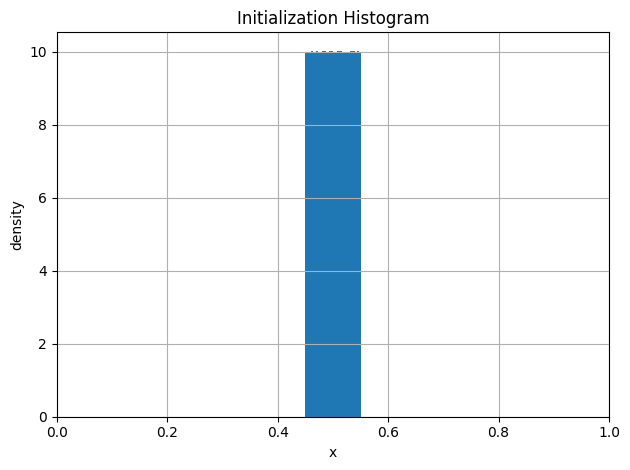

In [4]:
# X_0 = np.random.uniform(bc_1,bc_2, n_parts)
X_0 = np.random.uniform(.45,.55, n_parts)

plot_histogram(X_0, 30, title="Initialization Histogram", x_limit=x_bounds)

plt.tight_layout()
plt.show()

## Experiments

### Compore solutions with reflection, rejection and theta ($\theta =0.5$) boundary conditions

In [5]:


X_ref = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps
                                                     , b=b, sigma=sigma, boundary_type="reflection"
                                                     , boundaries=x_bounds)

X_rej  = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type="rejection", boundaries=x_bounds)

X_theta  = numerical_solution(method=euler_maruyama, X_0=X_0, dt=dt, n_steps=n_steps, b=b, sigma=sigma
                                                     , boundary_type=("theta", 0.5), boundaries=x_bounds)


### Load the data

In [5]:
X_ref = load_solution("ref_b-1_s-1_dt-0.01_N-10000000.npy")
X_rej = load_solution("rej_b-1_s-1_dt-0.01_N-10000000.npy")
X_theta = load_solution("('theta',0.5)_b-1_s-1_dt-0.01_N-10000000.npy")


### Plot the numerical and exact solutions

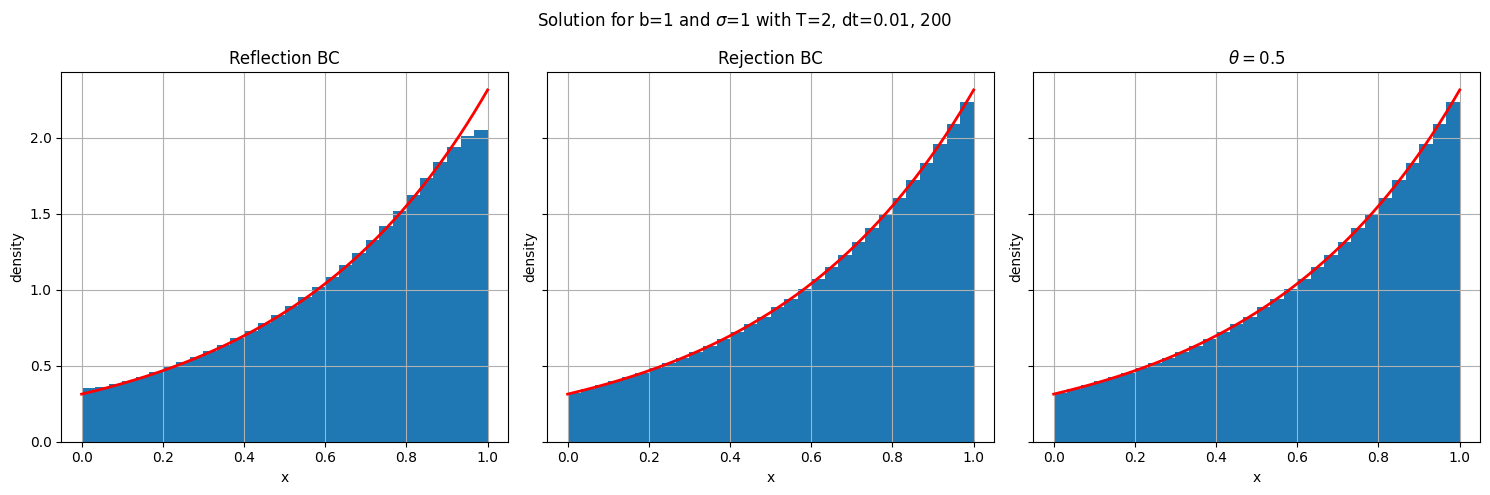

In [6]:
#compute the true solution
x_plot = np.linspace(x_bounds[0], x_bounds[1], 500)
p_exact = stationary_solution(x_plot, b, sigma, x_bounds)

# plot full histogram
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

fig.suptitle(fr"Solution for b={b(1,1)} and $\sigma$={sigma(1,1)} with {T=}, {dt=}, {n_steps}")

plot_histogram(X=X_ref, bins=30, ax=ax[0], title='Reflection BC',x_label='x', y_label='density', density=True
               , x_limit=None)
ax[0].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[1], title='Rejection BC', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[1].plot(x_plot, p_exact, "r", linewidth=2)

plot_histogram(X=X_rej, bins=30, ax=ax[2], title=r'$\theta=0.5$', x_label='x', y_label='density', density=True
               , x_limit=None)
ax[2].plot(x_plot, p_exact, "r", linewidth=2)

plt.tight_layout()
plt.show()



### Boundry Layer Inspection near $x=0$

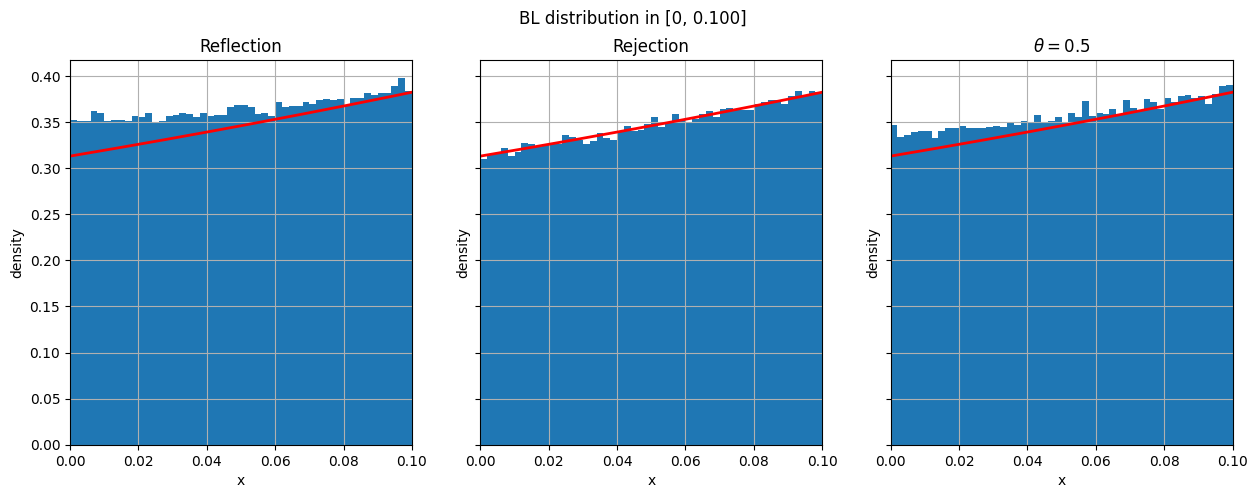

In [7]:
solutions = [X_ref, X_rej, X_theta]
names = ["Reflection", "Rejection", r"$\theta = 0.5$"]

width = epsilon
bins=50

x_plot = np.linspace(x_bounds[0], x_bounds[0] + width, 500)
p_true = stationary_solution(x_plot, b, sigma, x_bounds)

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
fig.suptitle(f"BL distribution in [{x_bounds[0]}, {x_bounds[0]+width:.3f}]")

for i, X_bc in enumerate(solutions):
    plot_local_density(X=X_bc, x_range=(x_bounds[0], x_bounds[0]+width), bins=bins, ax=ax[i], title=names[i])
    ax[i].plot(x_plot, p_true , "r", linewidth=2, label="True solution")



### Boundry Layer Inspection near $x=1$

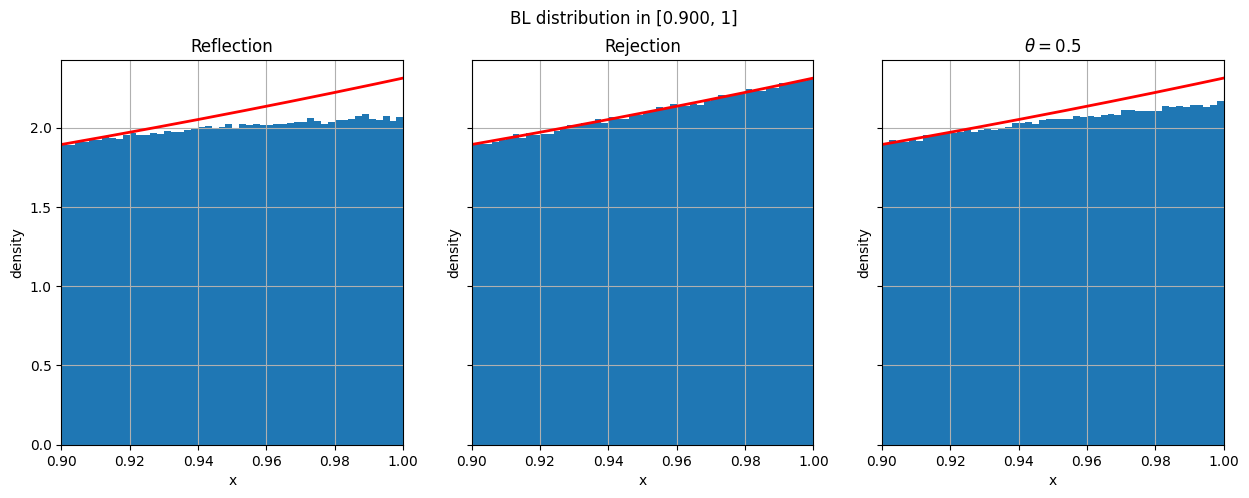

In [8]:
solutions = [X_ref, X_rej, X_theta]
names = ["Reflection", "Rejection", r"$\theta = 0.5$"]

width = epsilon
bins=50

x_plot = np.linspace(x_bounds[1]- width, x_bounds[1], 500)
p_true = stationary_solution(x_plot, b, sigma, x_bounds)

fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=True, sharey=True)
fig.suptitle(f"BL distribution in [{x_bounds[1]-width:.3f}, {x_bounds[1]}]")

for i, X_bc in enumerate(solutions):
    plot_local_density(X=X_bc, x_range=(x_bounds[1]-width, x_bounds[1]), bins=bins, ax=ax[i], title=names[i])
    ax[i].plot(x_plot, p_true , "r", linewidth=2, label="True solution")



### Inspect the error close to $x=1$ (`X_ref - p_true` vs `x`)

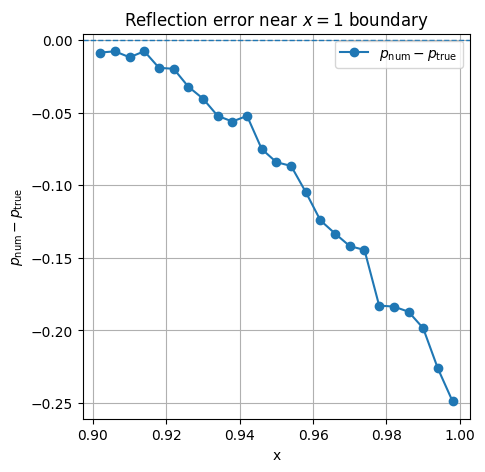

In [9]:

width = epsilon
bins=25

x_range = (x_bounds[1] - width, x_bounds[1])



#i should define a function for this part
edges = np.linspace(x_range[0], x_range[1], bins + 1)
counts, _ = np.histogram(X_ref, bins=edges)

bin_widths = np.diff(edges)
centres = 0.5 * (edges[:-1] + edges[1:])

p_num = counts / (len(X_ref) * bin_widths)


# true density at centres
p_true = stationary_solution(centres, b, sigma, x_bounds)

# error
error = p_num - p_true

plt.figure(figsize=(5, 5))

plt.plot(centres, error, marker="o", linestyle="-", label=r"$p_{\mathrm{num}} - p_{\mathrm{true}}$")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title(fr"Reflection error near $x=1$ boundary")
plt.xlabel("x")
plt.ylabel(r"$p_{\mathrm{num}} - p_{\mathrm{true}}$")
plt.grid(True)
plt.legend()

plt.show()



### do the same but for stretched $X=\frac{1}{\epsilon} x$

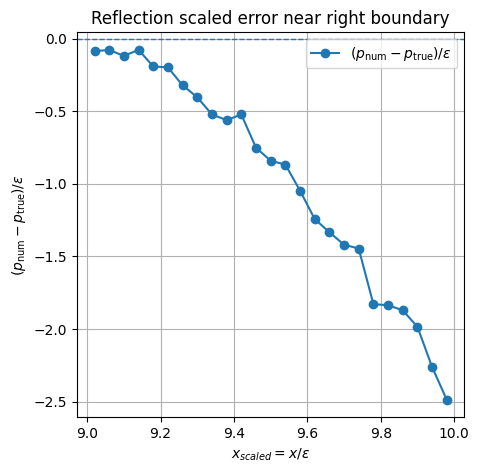

In [10]:

bins = 25


x_range = (x_bounds[1] - epsilon, x_bounds[1])

edges = np.linspace(x_range[0], x_range[1], bins + 1)
counts, _ = np.histogram(X_ref, bins=edges)

bin_widths = np.diff(edges)
centres = 0.5 * (edges[:-1] + edges[1:])

p_num = counts / (len(X_ref) * bin_widths)

p_true = stationary_solution(centres, b, sigma, x_bounds)


error = p_num - p_true

x_scaled = centres / epsilon
error_scaled  = error / epsilon

plt.figure(figsize=(5, 5))

plt.plot(x_scaled, error_scaled, marker="o", linestyle="-"
         , label=r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\epsilon$")

plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Reflection scaled error near right boundary")
plt.xlabel(r"$x_{scaled} = x/\epsilon$")
plt.ylabel(r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\epsilon$")
plt.grid(True)
plt.legend()

plt.show()

### Use prediceted error

$$\approx P^{(1)}(X) - Xp^{\prime}(x=1) + O(\epsilon)$$

with $P^{(1)} \sim 2 \frac{b-\sigma(x=1) \sigma^{\prime}(x=1)}{\sigma^2(x=1)} p^0_n(x=1)X$

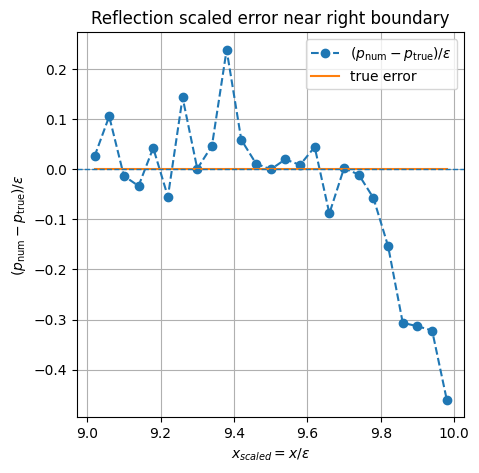

In [43]:

bins = 25
dt = 0.01

epsilon = np.sqrt(dt)

x_range = (x_bounds[1] - epsilon, x_bounds[1])

edges = np.linspace(x_range[0], x_range[1], bins + 1)
counts, _ = np.histogram(X_ref, bins=edges)

bin_widths = np.diff(edges)
centres = 0.5 * (edges[:-1] + edges[1:])

p_num = counts / (len(X_ref) * bin_widths)

p_true = stationary_solution(centres, b, sigma, x_bounds)


error = p_num - p_true

x_scaled = centres / epsilon

error_scaled  = error / epsilon


# p at the boundary
p_0_xmax = stationary_solution(np.array([x_bounds[1]]), b, sigma, x_bounds)[0]

sigma_prime = 0 #this is for the case of constant diffusion

# this is similar to P^(1) as X goes to inf
P_1 = 2 *(b(0,0)/sigma(0,0)**2) * x_scaled * p_0_xmax

p_true_prime_xmax = stationary_solution_prime(np.array([x_bounds[1]]), b, sigma, x_bounds)[0]

error_true = P_1 - x_scaled* p_true_prime_xmax

plt.figure(figsize=(5, 5))

plt.plot(x_scaled, error_scaled, marker="o", linestyle="--"
         , label=r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\epsilon$")

plt.plot(x_scaled, error_true, linestyle="-"
         , label=r"true error")


plt.axhline(0, linestyle="--", linewidth=1)

plt.title("Reflection scaled error near right boundary")
plt.xlabel(r"$x_{scaled} = x/\epsilon$")
plt.ylabel(r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\epsilon$")
plt.grid(True)
plt.legend()

plt.show()

### Plot multiple solutions varying dt

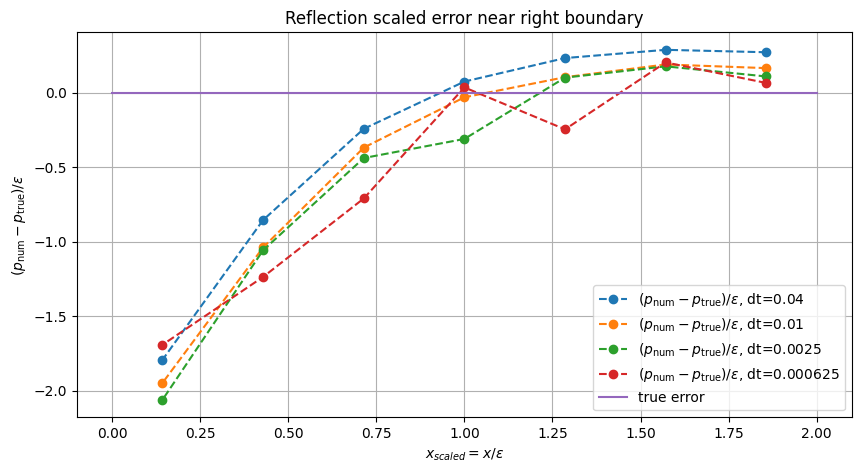

In [ ]:

bins = 7

solutions = ["ref_b-1_s-1_dt-0.04_N-10000000.npy",
             "ref_b-1_s-1_dt-0.01_N-10000000.npy",
             "ref_b-1_s-1_dt-0.0025_N-10000000.npy",
             "ref_b-1_s-1_dt-0.000625_N-10000000.npy"]



plt.figure(figsize=(10, 5))


for solution in solutions:

    X_ref = load_solution(solution)
    dt = float(solution[solution.find("dt-")+3: solution.find("_N")])

    epsilon = np.sqrt(dt)

    x_range = (x_bounds[1] - 2*epsilon, x_bounds[1])

    edges = np.linspace(x_range[0], x_range[1], bins + 1)
    bin_widths = np.diff(edges)
    centres = 0.5 * (edges[:-1] + edges[1:])


    x_scaled = (x_bounds[1] - centres) / epsilon



    counts, _ = np.histogram(X_ref, bins=edges)


    p_num = counts / (len(X_ref) * bin_widths)

    p_true = stationary_solution(centres, b, sigma, x_bounds)


    error = p_num - p_true

    error_scaled  = error / epsilon

    plt.plot(x_scaled, error_scaled, marker="o", linestyle="--"
         , label=r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\epsilon$"+f", {dt=}")



# p at the boundary
p_0_xmax = stationary_solution(np.array([x_bounds[1]]), b, sigma, x_bounds)[0]

sigma_prime = 0 #this is for the case of constant diffusion

X_plot = np.linspace(0, 2 , 200)

# this is similar to P^(1) as X goes to inf
P_1 = 2 *(b(0,0)/sigma(0,0)**2) * X_plot * p_0_xmax

p_true_prime_xmax = stationary_solution_prime(np.array([x_bounds[1]]), b, sigma, x_bounds)[0]

#this quantitiy is 0 for this problem, need more complicated problem to see diffrent curve
error_true = P_1 - X_plot* p_true_prime_xmax 


plt.plot(X_plot, error_true, linestyle="-", label=r"true error")


plt.title("Reflection scaled error near right boundary")
plt.xlabel(r"$x_{scaled} = x/\epsilon$")
plt.ylabel(r"$(p_{\mathrm{num}} - p_{\mathrm{true}})/\epsilon$")
plt.grid(True)
plt.legend()

plt.show()

np.float64(4.626070570998663)